# Transformer Architecture and Text Classification

The Transformer combines self-attention, multi-head attention, positional information, residual connections, layer normalization, and feed-forward networks.

This notebook develops the complete architecture and then applies a Transformer encoder to IMDB sentiment classification.

The learning progression is:

```text
limitations of recurrence
→ attention
→ self-attention
→ multi-head attention
→ positional information
→ Transformer encoder
→ Transformer decoder
→ Transformer text classifier
```


## Transformer Encoder and Decoder


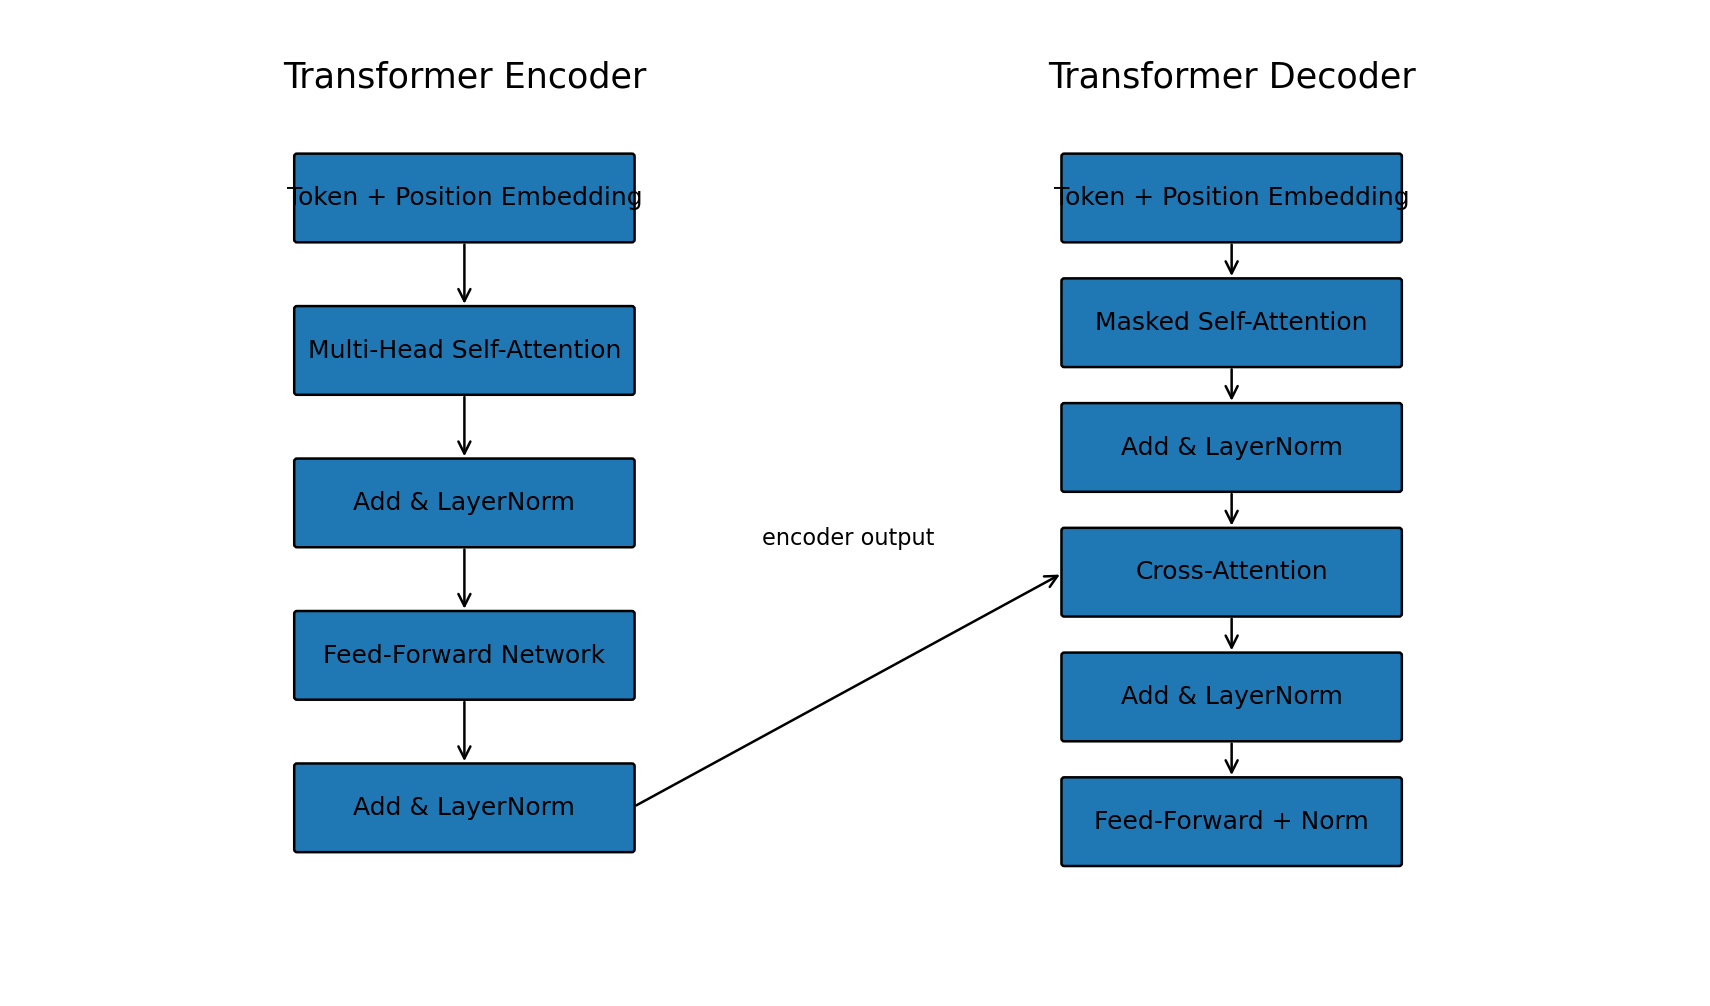

### Encoder

The encoder repeatedly applies:

1. multi-head self-attention,
2. residual connection and layer normalization,
3. position-wise feed-forward network,
4. another residual connection and layer normalization.

### Decoder

The decoder adds two important ideas:

1. **masked self-attention** so future output tokens cannot be seen,
2. **cross-attention** where decoder queries attend to encoder keys and values.

For classification, only the encoder is required.


## Import Libraries


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:',tf.__version__)


TensorFlow version: 2.20.0


## Residual Connections and Layer Normalization


A Transformer block does not simply stack attention and Dense layers.

Residual connections provide a direct path around each sublayer:

$$
x_{out}=LayerNorm(x+Sublayer(x))
$$

This helps optimization and allows information from the original representation to remain available.


## Position-Wise Feed-Forward Network


After self-attention mixes information across token positions, the feed-forward network transforms each token representation independently.

A common form is:

$$
FFN(x)=W_2\,ReLU(W_1x+b_1)+b_2
$$


## Token and Position Embedding Layer


In [2]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self,maxlen,vocab_size,embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size,embed_dim)
        self.pos_emb = layers.Embedding(maxlen,embed_dim)

    def call(self,x):
        positions = tf.range(start=0,limit=tf.shape(x)[-1],delta=1)
        return self.token_emb(x)+self.pos_emb(positions)


Unlike the sinusoidal encoding in the previous notebook, this layer uses **learned positional embeddings**. Both approaches provide position information.


## Transformer Encoder Block


In [3]:
class TransformerEncoder(layers.Layer):
    def __init__(self,embed_dim,num_heads,ff_dim,dropout=0.1):
        super().__init__()
        self.attention = layers.MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim//num_heads)
        self.ffn = tf.keras.Sequential([layers.Dense(ff_dim,activation='relu'),layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self,inputs,training=None,mask=None):
        attention_mask = None

        if mask is not None:
            attention_mask = mask[:,tf.newaxis,:]

        attn_output,attn_scores = self.attention(inputs,inputs,attention_mask=attention_mask,return_attention_scores=True,training=training)
        x = self.norm1(inputs+self.dropout1(attn_output,training=training))
        ffn_output = self.ffn(x)
        output = self.norm2(x+self.dropout2(ffn_output,training=training))
        return output,attn_scores

## Transformer Decoder Block


A decoder block uses causal self-attention followed by cross-attention to the encoder output.

The following layer shows the basic structure. It is included to make the encoder-decoder architecture complete even though the IMDB classification task below only needs the encoder.


In [4]:
class TransformerDecoder(layers.Layer):
    def __init__(self,embed_dim,num_heads,ff_dim,dropout=0.1):
        super().__init__()
        self.self_attention = layers.MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim//num_heads)
        self.cross_attention = layers.MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim//num_heads)
        self.ffn = tf.keras.Sequential([layers.Dense(ff_dim,activation='relu'),layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)

    def call(self,inputs,encoder_output,training=None):
        x = self.self_attention(inputs,inputs,use_causal_mask=True,training=training)
        x = self.norm1(inputs+self.dropout1(x,training=training))
        y = self.cross_attention(x,encoder_output,training=training)
        x = self.norm2(x+self.dropout2(y,training=training))
        y = self.ffn(x)
        return self.norm3(x+self.dropout3(y,training=training))


## Check Encoder and Decoder Shapes


In [5]:
batch_size = 2
seq_len = 10
embed_dim = 32

encoder_input = tf.random.normal((batch_size,seq_len,embed_dim))
decoder_input = tf.random.normal((batch_size,seq_len,embed_dim))

encoder_layer = TransformerEncoder(embed_dim=32,num_heads=4,ff_dim=64)
encoder_output,attention_scores = encoder_layer(encoder_input)

decoder_layer = TransformerDecoder(embed_dim=32,num_heads=4,ff_dim=64)
decoder_output = decoder_layer(decoder_input,encoder_output)

print('Encoder output shape:',encoder_output.shape)
print('Attention score shape:',attention_scores.shape)
print('Decoder output shape:',decoder_output.shape)


Encoder output shape: (2, 10, 32)
Attention score shape: (2, 4, 10, 10)
Decoder output shape: (2, 10, 32)


## IMDB Sentiment Classification


The IMDB dataset contains movie reviews labeled as negative or positive.

The input reviews are already represented as integer word sequences. They are padded to a fixed length before training.

Three models are compared:

1. Dense baseline with global average pooling,
2. LSTM sequence model,
3. Transformer encoder classifier.

This comparison connects the earlier portfolio sections to the Transformer architecture.


## Load and Pad the IMDB Dataset


In [6]:
vocab_size = 20000

maxlen = 200

(x_train,y_train),(x_test,y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

x_train = tf.keras.utils.pad_sequences(x_train,maxlen=maxlen,padding='post',truncating='post')

x_test = tf.keras.utils.pad_sequences(x_test,maxlen=maxlen,padding='post',truncating='post')

print('Training data:',x_train.shape)

print('Test data:',x_test.shape)

print('Training labels:',y_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (25000, 200)
Test data: (25000, 200)
Training labels: (25000,)


## Create Training and Validation Sets


In [7]:
x_val = x_train[-5000:]

y_val = y_train[-5000:]

x_train_model = x_train[:-5000]

y_train_model = y_train[:-5000]


print('Model training data:',x_train_model.shape)

print('Validation data:',x_val.shape)

print('Test data:',x_test.shape)



Model training data: (20000, 200)
Validation data: (5000, 200)
Test data: (25000, 200)


### Verify Right Padding

Because the LSTM uses `mask_zero=True`, the zero-padding must appear only at the **end** of each sequence when cuDNN acceleration is used. This check confirms that the token mask changes only from `True` to `False`, never back to `True`.

In [8]:
sample_mask = x_train_model[:5] != 0

print('First sample token mask:')
print(sample_mask[0])

print('Right padding verified for first 5 samples:',np.all(np.diff(sample_mask.astype(int),axis=1) <= 0))

First sample token mask:
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  

## Common Training Settings


In [9]:
epochs = 100

batch_size = 128

def get_callbacks():
    return [EarlyStopping(monitor='val_accuracy',patience=2,restore_best_weights=True)]

# 1. Dense Baseline


The Dense baseline embeds the words and then averages all token embeddings.

This is efficient, but the global average removes most sequence-order information before classification.


In [10]:
dense_model = tf.keras.Sequential([
    layers.Input(shape=(maxlen,),dtype=tf.int32),
    layers.Embedding(vocab_size,32,mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

dense_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

dense_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641,089 (2.45 MB)

 Trainable params: 641,089 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate the Dense Baseline


In [11]:
start = time.time()

dense_history = dense_model.fit(x_train_model,y_train_model,validation_data=(x_val,y_val),epochs=epochs,batch_size=batch_size,callbacks=get_callbacks(),verbose=1)

dense_time = time.time()-start
dense_loss,dense_acc = dense_model.evaluate(x_test,y_test,verbose=0)

print('Dense test accuracy:',dense_acc)
print('Dense training time:',dense_time)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7056 - loss: 0.6301 - val_accuracy: 0.8212 - val_loss: 0.4943
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8554 - loss: 0.3793 - val_accuracy: 0.8616 - val_loss: 0.3370
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8969 - loss: 0.2680 - val_accuracy: 0.8738 - val_loss: 0.3043
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9219 - loss: 0.2135 - val_accuracy: 0.8790 - val_loss: 0.2961
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9391 - loss: 0.1739 - val_accuracy: 0.8808 - val_loss: 0.2986
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9542 - loss: 0.1419 - val_accuracy: 0.8812 - val_loss: 0.3077
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9658 - loss: 0.1150 - val_accuracy: 0.8818 - val_loss: 0.3219
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9740 - loss: 0.0922 - val_acc

# 2. LSTM Baseline


The LSTM preserves sequence order and carries information recurrently from one token to the next.

Its limitation is that the hidden state is updated sequentially, so later positions depend on earlier recurrent computations.


In [12]:
lstm_model = tf.keras.Sequential([
    layers.Input(shape=(maxlen,),dtype=tf.int32),
    layers.Embedding(vocab_size,32,mask_zero=True),
    layers.LSTM(64),
    layers.Dense(1,activation='sigmoid')
])

lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664,897 (2.54 MB)

 Trainable params: 664,897 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate the LSTM


In [13]:
start = time.time()

lstm_history = lstm_model.fit(x_train_model,y_train_model,validation_data=(x_val,y_val),epochs=epochs,batch_size=batch_size,callbacks=get_callbacks(),verbose=1)

lstm_time = time.time()-start
lstm_loss,lstm_acc = lstm_model.evaluate(x_test,y_test,verbose=0)

print('LSTM test accuracy:',lstm_acc)
print('LSTM training time:',lstm_time)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7381 - loss: 0.4995 - val_accuracy: 0.8620 - val_loss: 0.3370
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8982 - loss: 0.2639 - val_accuracy: 0.8598 - val_loss: 0.3913
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9261 - loss: 0.2058 - val_accuracy: 0.8584 - val_loss: 0.3408
LSTM test accuracy: 0.8482400178909302
LSTM training time: 12.759581327438354


# 3. Transformer Encoder Classifier


The Transformer encoder does not pass information through a recurrent hidden state. Self-attention allows each token representation to directly combine information from the other positions.

The classifier uses:

```text
integer tokens
→ token + position embeddings
→ Transformer encoder
→ global pooling
→ Dense classifier
```


In [14]:
embed_dim = 32
num_heads = 4
ff_dim = 64

inputs = layers.Input(shape=(maxlen,),dtype=tf.int32)
padding_mask = layers.Lambda(lambda x: tf.not_equal(x,0))(inputs)

x = TokenAndPositionEmbedding(maxlen,vocab_size,embed_dim)(inputs)
x,attention_scores = TransformerEncoder(embed_dim,num_heads,ff_dim,dropout=0.1)(x,mask=padding_mask)
x = layers.GlobalAveragePooling1D()(x,mask=padding_mask)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32,activation='relu')(x)
outputs = layers.Dense(1,activation='sigmoid')(x)

transformer_model = tf.keras.Model(inputs,outputs)
attention_model = tf.keras.Model(inputs,attention_scores)

transformer_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
transformer_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 200, 32)   │    646,400 │ input_layer_4[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 200)       │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ [(None, 200, 32), │      8,544 │ token_and_positi… │
│ (TransformerEncode… │ (None, 4, 200,    │            │ lambda[0][0]      │
│                     │ 200)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      1,056 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 656,033 (2.50 MB)

 Trainable params: 656,033 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate the Transformer


In [15]:
start = time.time()

transformer_history = transformer_model.fit(x_train_model,y_train_model,validation_data=(x_val,y_val),epochs=epochs,batch_size=batch_size,callbacks=get_callbacks(),verbose=1)

transformer_time = time.time()-start
transformer_loss,transformer_acc = transformer_model.evaluate(x_test,y_test,verbose=0)

print('Transformer test accuracy:',transformer_acc)
print('Transformer training time:',transformer_time)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.7854 - loss: 0.4432 - val_accuracy: 0.8754 - val_loss: 0.3026
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8973 - loss: 0.2542 - val_accuracy: 0.8668 - val_loss: 0.3319
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9262 - loss: 0.1968 - val_accuracy: 0.8560 - val_loss: 0.4025
Transformer test accuracy: 0.8563200235366821
Transformer training time: 23.124347448349


## Compare Dense, LSTM, and Transformer


In [16]:
comparison = pd.DataFrame({
    'Model':['Dense average','LSTM','Transformer encoder'],
    'Parameters':[dense_model.count_params(),lstm_model.count_params(),transformer_model.count_params()],
    'Test Accuracy':[dense_acc,lstm_acc,transformer_acc],
    'Training Time (s)':[dense_time,lstm_time,transformer_time]
})

comparison.sort_values('Test Accuracy',ascending=False).reset_index(drop=True)


,Model,Parameters,Test Accuracy,Training Time (s)
0,Transformer encoder,656033,0.85632,23.124347
1,Dense average,641089,0.85128,9.691703
2,LSTM,664897,0.84824,12.759581


## Plot Validation Accuracy


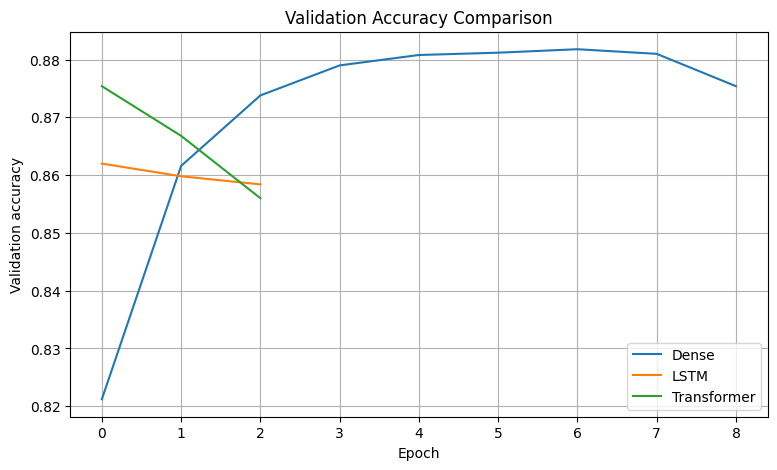

In [17]:
plt.figure(figsize=(9,5))
plt.plot(dense_history.history['val_accuracy'],label='Dense')
plt.plot(lstm_history.history['val_accuracy'],label='LSTM')
plt.plot(transformer_history.history['val_accuracy'],label='Transformer')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Validation Accuracy Comparison')
plt.grid(True)
plt.legend()
plt.show()


## Inspect Transformer Attention Scores


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_1' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Attention score shape: (1, 4, 200, 200)


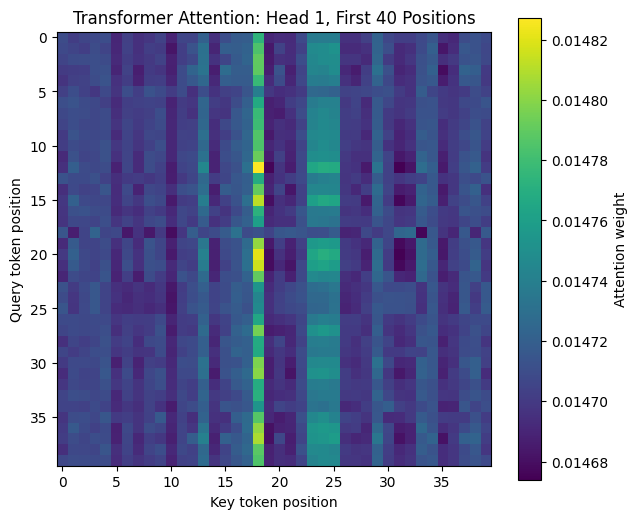

In [18]:
sample = x_test[:1]
sample_scores = attention_model.predict(sample,verbose=0)

print('Attention score shape:',sample_scores.shape)

head_1 = sample_scores[0,0]

plt.figure(figsize=(7,6))
plt.imshow(head_1[:40,:40])
plt.colorbar(label='Attention weight')
plt.xlabel('Key token position')
plt.ylabel('Query token position')
plt.title('Transformer Attention: Head 1, First 40 Positions')
plt.show()


The attention matrix shows which token positions receive attention from each query position. The exact pattern becomes meaningful only after training.


## Why Transformers Improve Sequence Modeling


The progression from recurrent models to Transformers can now be summarized directly.

```text
RNN / LSTM / GRU
→ sequence order is modeled through recurrent state
→ useful memory can be learned
→ computation is inherently sequential

Attention
→ the current query can directly access relevant sequence positions

Self-attention
→ every token can directly relate to other tokens

Transformer
→ self-attention + position information + feed-forward blocks
→ sequence modeling without recurrence
```

Transformers do not automatically dominate every recurrent model. Their main architectural advantages are direct long-range interactions and parallel attention computation. Their main limitation is that standard self-attention requires an attention matrix whose cost grows approximately with the square of sequence length.


## Key Takeaways


- The Transformer encoder is built from self-attention, residual connections, layer normalization, and feed-forward networks.
- The decoder adds causal self-attention and encoder-decoder cross-attention.
- Positional information is required because self-attention itself does not provide recurrence.
- Transformers allow direct interactions between distant sequence positions.
- Dense averaging loses most order information.
- LSTM preserves order but processes recurrently.
- Transformer encoders model order through position information and token-to-token self-attention.
- Standard self-attention has quadratic sequence-length cost.
